# Определение возраста покупателей

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:

1. Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы
2. Контролировать добросовестность кассиров при продаже алкоголя

Необходимо построить модель, которая по фотографии определит приблизительный возраст человека. В распоряжении набор фотографий людей с указанием возраста.

In [1]:
import pandas as pd 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
PATH = r'/datasets/faces'
IMAGE_PATH = r'/datasets/faces/final_files'
DF_PATH = r'/datasets/faces/labels.csv'

## Исследовательский анализ данных

In [3]:
df = pd.read_csv(DF_PATH)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


Можно набросать скрипт, проверяющий, существуют ли эти файлы на самом деле, но мы знаем, что таких ньюансов тут нет

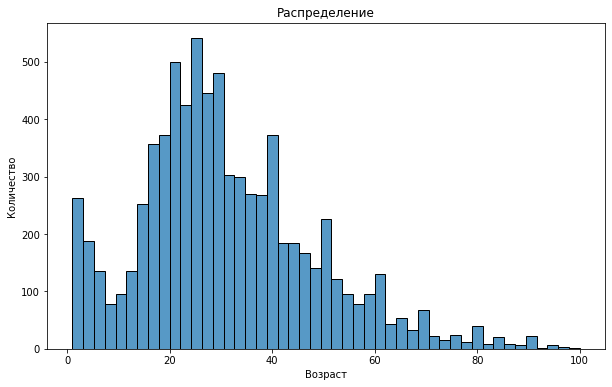

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='real_age')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.title('Распределение')
plt.show();

В датасете преобладают молодые взрослые - вероятно, он был собран из онлайн-источников. В нём так же много детей (в том числе и в возрасте, в котором им по закону вообще ничего продавать нельзя (младше 6 лет) и в котором ни один адекватный родитель ребёнка одного не отправит) и наблюдаются "пики" на "круглых" датах (40, 50, 60, 70, 80 лет) - возможно, они туда были включены специально, а возможно, что при составлении датасета у спрашивали/смотрели возраст в соцсетях, где он был округлён. В любом случае, распределение неравномерно, но ЦА магазина *примерно* так и распределена, а наличие большого количества подростков и молодых взрослых поможет с контролем добросовестности кассиров при продаже алкоголя (и сигарет?)

Сомневаюсь, что фото новорожденных и грудничков сильно нужны данной модели, но обучать её сказано на серверах практикума, куда ты даёшь лишь часть кода (= чёрный ящик) и мне попросту не хочется что-то менять в рабочем скрипте - работает, не трогай, а то опять получишь ошибку "ваш код делает что-то не то, сделайте по-другому"

In [6]:
train_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_datagen_flow = train_datagen.flow_from_dataframe(
    df,
    IMAGE_PATH,
    x_col='file_name',
    y_col='real_age',
    target_size=(224, 224),
    batch_size=64,
    class_mode='raw',
    subset='training',
    seed=12345)

Found 7591 validated image filenames.


In [7]:
def show_images(generator, num_images):
    images, labels = next(generator)
    plt.figure(figsize=(20, 20))
    for i in range(num_images):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
    plt.subplots_adjust(wspace=0.05, hspace=0.001)
    plt.show()

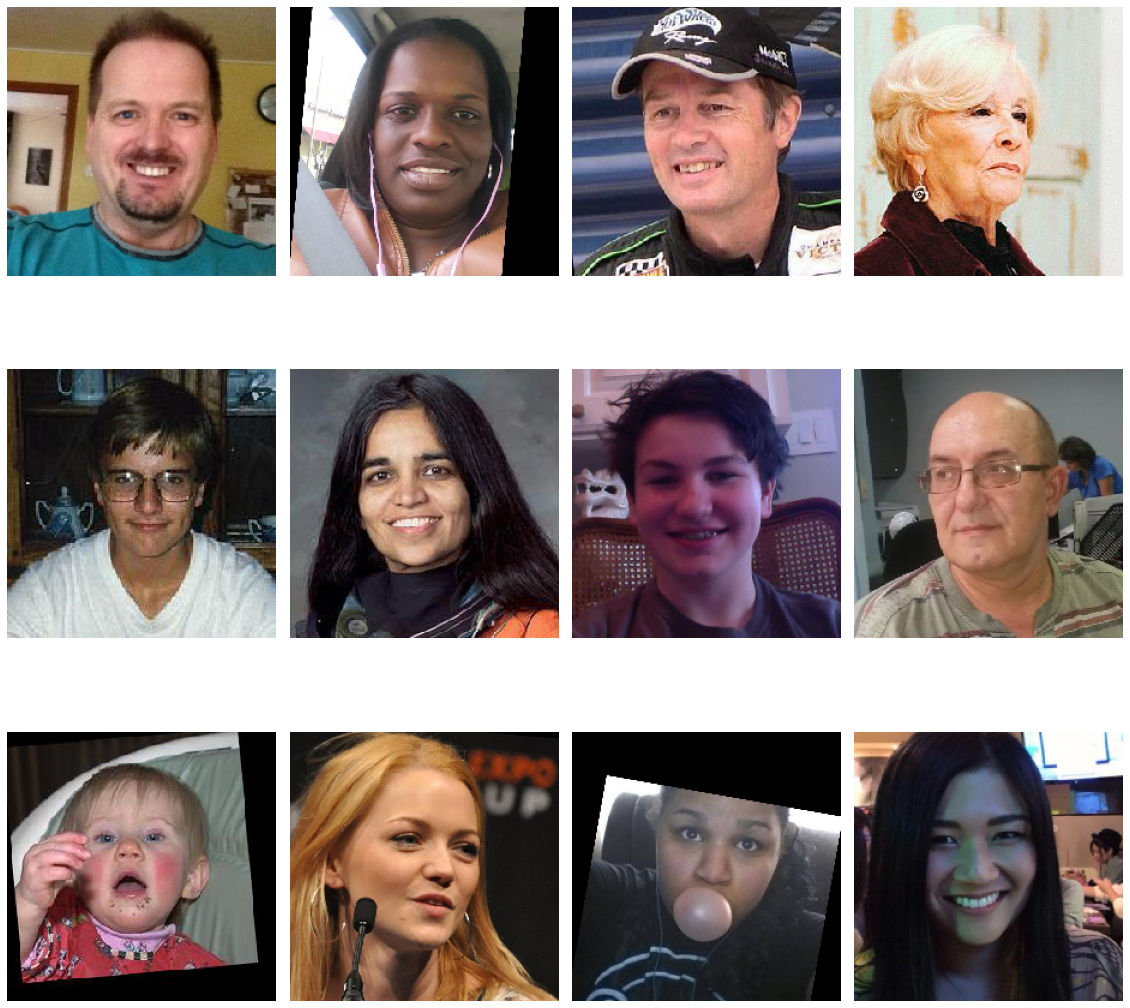

In [8]:
show_images(train_datagen_flow, 12)

Некоторые картинки повёрнуты - можно сэкономить на аугментациях, некоторые зашакалены куда сильнее, чем нормальная компрессия с камеры, но и так сойдёт - если модель смогла что-то понять на таком датасете, то и на кадрах с камеры она тоже сможет всё правильно понять

## Обучение модели

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
import os
from tensorflow.keras.applications import ResNet50
 
def load_train(path):
    train_datagen = ImageDataGenerator(validation_split=0.25, rescale=1/255)
    df = pd.read_csv(os.path.join(path, 'labels.csv'))
    train_datagen_flow = train_datagen.flow_from_dataframe(
        df,
        os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=48,
        class_mode='raw',
        subset='training',
        seed=12345
    )
 
    return train_datagen_flow
    
def load_test(path):
    train_datagen = ImageDataGenerator(validation_split=0.25, rescale=1/255)
    df = pd.read_csv(os.path.join(path, 'labels.csv'))
    train_datagen_flow = train_datagen.flow_from_dataframe(
        df,
        os.path.join(path, 'final_files'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=48,
        class_mode='raw',
        subset='validation',
        seed=12345
    )
 
    return train_datagen_flow
 
def create_model(input_shape):

    backbone = ResNet50(input_shape=input_shape,
                        weights='/datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5', 
                        include_top=False)
    #backbone.trainable = False
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))
    
    optimizer = Adam(lr=0.00006)
    model.compile(optimizer=optimizer,
                  loss='mse',
                  metrics=['mae'])
 
    return model
 
def train_model(model, train_data, test_data, batch_size=None, epochs=25,
                steps_per_epoch=None, validation_steps=None):
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)
    if validation_steps is None:
        validation_steps = len(test_data)
    early_stopping = EarlyStopping(monitor='val_mae', patience=5, restore_best_weights=True)
    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size, epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2, shuffle=True, callbacks=[early_stopping])

    return model

```

```

<class 'tensorflow.python.keras.engine.sequential.Sequential'>

WARNING:tensorflow:sample_weight modes were coerced from

  ...

    to  

  ['...']

WARNING:tensorflow:sample_weight modes were coerced from

  ...

    to  

  ['...']

Train for 119 steps, validate for 40 steps

Epoch 1/25

2024-07-17 23:49:26.486417: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10

2024-07-17 23:49:26.966420: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7

119/119 - 70s - loss: 323.0681 - mae: 12.9617 - val_loss: 904.6109 - val_mae: 25.2423

Epoch 2/25

119/119 - 46s - loss: 63.2617 - mae: 5.9414 - val_loss: 883.5964 - val_mae: 24.8646

Epoch 3/25

119/119 - 44s - loss: 29.2896 - mae: 4.1555 - val_loss: 909.1154 - val_mae: 25.3157

Epoch 4/25

119/119 - 45s - loss: 16.0835 - mae: 3.0569 - val_loss: 510.5313 - val_mae: 17.3342

Epoch 5/25

119/119 - 46s - loss: 12.0374 - mae: 2.6383 - val_loss: 213.2477 - val_mae: 10.6162

Epoch 6/25

119/119 - 45s - loss: 9.9184 - mae: 2.4061 - val_loss: 139.3589 - val_mae: 8.8367

Epoch 7/25

119/119 - 45s - loss: 8.8876 - mae: 2.2497 - val_loss: 86.3164 - val_mae: 7.1161

Epoch 8/25

119/119 - 44s - loss: 8.9530 - mae: 2.2806 - val_loss: 75.5007 - val_mae: 6.5510

Epoch 9/25

119/119 - 41s - loss: 8.9451 - mae: 2.2705 - val_loss: 71.0785 - val_mae: 6.3961

Epoch 10/25

119/119 - 41s - loss: 8.4194 - mae: 2.2050 - val_loss: 68.9483 - val_mae: 6.3384

Epoch 11/25

119/119 - 45s - loss: 7.1990 - mae: 2.0510 - val_loss: 75.5879 - val_mae: 6.7471

Epoch 12/25

119/119 - 51s - loss: 5.9917 - mae: 1.8832 - val_loss: 72.9820 - val_mae: 6.3597

Epoch 13/25

119/119 - 49s - loss: 5.6559 - mae: 1.7948 - val_loss: 69.9776 - val_mae: 6.2892

Epoch 14/25

119/119 - 50s - loss: 5.4398 - mae: 1.7596 - val_loss: 80.3212 - val_mae: 6.7006

Epoch 15/25

119/119 - 48s - loss: 5.0175 - mae: 1.6831 - val_loss: 68.8536 - val_mae: 6.2276

Epoch 16/25

119/119 - 50s - loss: 4.1135 - mae: 1.5225 - val_loss: 72.4587 - val_mae: 6.3112

Epoch 17/25

119/119 - 51s - loss: 3.8786 - mae: 1.4552 - val_loss: 70.6866 - val_mae: 6.5239

Epoch 18/25

119/119 - 51s - loss: 3.8640 - mae: 1.4449 - val_loss: 69.0671 - val_mae: 6.2010

Epoch 19/25

119/119 - 48s - loss: 3.5894 - mae: 1.4172 - val_loss: 69.5004 - val_mae: 6.4467

Epoch 20/25

119/119 - 50s - loss: 3.2978 - mae: 1.3669 - val_loss: 64.0410 - val_mae: 6.0471

Epoch 21/25

119/119 - 50s - loss: 3.2612 - mae: 1.3553 - val_loss: 68.1378 - val_mae: 6.1727

Epoch 22/25

119/119 - 50s - loss: 3.1236 - mae: 1.3071 - val_loss: 67.8790 - val_mae: 6.3602

Epoch 23/25

119/119 - 48s - loss: 2.9307 - mae: 1.2836 - val_loss: 64.4092 - val_mae: 6.0622

Epoch 24/25

119/119 - 51s - loss: 2.9846 - mae: 1.2886 - val_loss: 66.5954 - val_mae: 6.2996

Epoch 25/25

119/119 - 50s - loss: 3.0400 - mae: 1.2906 - val_loss: 62.0446 - val_mae: 5.9650

WARNING:tensorflow:sample_weight modes were coerced from

  ...

    to  

  ['...']

40/40 - 12s - loss: 62.0446 - mae: 5.9650

Test MAE: 5.9650


```

## Анализ обученной модели

К предыдущему блоку задания шла ссылка на "эталонный" результат MAE в 5.4 и статью, основной вклад которой заключался в Residual DEX - после обучения одной модели вторая модель обучалась на её остатках (ошибке) - и во время использования к ответу основной модели прибавлялось предсказание остатка 

В нашем же случае модель для решения задачи одновременно простая и сложная - простая так как состоит тупо из 3х блоков (+настройка оптимизатора), сложная так как первый же блок тянет за собой целый ResNet50 - который пусть и легче (в виде файла), чем VGG16 из статьи, но при этом более сложная и продвинутая в плане внутренней архитектуры

Был получен результат в 5.965 (задание требовало MAE меньше 8, а 7 и ниже преподносилось как "отличный результат"), при этом модель несколько переобучилась - заморозка слоёв не применялась. Результат удолетворяет ТЗ, однако модель, при желании, можно доработать, например, попробовав применить метод из статьи: у них и предобработка (грубо и дёшево найти лицо, обрезать его + 40% вокруг), и предсказание ошибок (вторая модель предсказывает остаток и он прибваляется к выводу основной модели). Или можно попробовать поиграться с заморозкой слоёв (датасет не очень большой), количеством эпох и скоростью обучения - однако результат и так близок к эталонному, вычислительные ресурсы не резиновые (серверов с GPU мало) и вообще время - деньги

## Чек-лист

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Исследовательский анализ данных выполнен
- [x]  Результаты исследовательского анализа данных перенесены в финальную тетрадь
- [x]  MAE модели не больше 8
- [x]  Код обучения модели скопирован в финальную тетрадь
- [x]  Результат вывода модели на экран перенесён в финальную тетрадь
- [x]  По итогам обучения модели сделаны выводы